In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from pathlib import Path

In [3]:
project_folder = Path('/content/drive/MyDrive/Bellabeat Case Study')

data_folder = (
    project_folder
    / '01 Original Data'
    / 'mturkfitbit_export_4.12.16-5.12.16'
    / 'Fitabase Data 4.12.16-5.12.16'
)

print(data_folder)

/content/drive/MyDrive/Bellabeat Case Study/01 Original Data/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16


In [5]:
csv_files = sorted(data_folder.glob('*.csv'))

print(f'Number of CSV files found: {len(csv_files)}')

for file in csv_files:
    print(file.name)

Number of CSV files found: 18
dailyActivity_merged.csv
dailyCalories_merged.csv
dailyIntensities_merged.csv
dailySteps_merged.csv
heartrate_seconds_merged.csv
hourlyCalories_merged.csv
hourlyIntensities_merged.csv
hourlySteps_merged.csv
minuteCaloriesNarrow_merged.csv
minuteCaloriesWide_merged.csv
minuteIntensitiesNarrow_merged.csv
minuteIntensitiesWide_merged.csv
minuteMETsNarrow_merged.csv
minuteSleep_merged.csv
minuteStepsNarrow_merged.csv
minuteStepsWide_merged.csv
sleepDay_merged.csv
weightLogInfo_merged.csv


In [6]:
daily_activity_file = data_folder / "dailyActivity_merged.csv"
sleep_file = data_folder / "sleepDay_merged.csv"

daily_activity = pd.read_csv(daily_activity_file)
sleep = pd.read_csv(sleep_file)

print("Daily activity rows and columns:", daily_activity.shape)
print("Sleep rows and columns:", sleep.shape)

Daily activity rows and columns: (940, 15)
Sleep rows and columns: (413, 5)


In [7]:
print("Daily activity columns:")
print(daily_activity.columns.tolist())

print("\nDaily activity data types:")
print(daily_activity.dtypes)

print("\nSleep columns:")
print(sleep.columns.tolist())

print("\nSleep data types:")
print(sleep.dtypes)

Daily activity columns:
['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']

Daily activity data types:
Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object

Sleep columns:
['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed

In [8]:
daily_activity["ActivityDate"] = pd.to_datetime(
    daily_activity["ActivityDate"],
    errors="coerce"
)

sleep["SleepDay"] = pd.to_datetime(
    sleep["SleepDay"],
    errors="coerce"
).dt.date

daily_activity["ActivityDate"] = daily_activity["ActivityDate"].dt.date

print("Invalid ActivityDate values:", daily_activity["ActivityDate"].isna().sum())
print("Invalid SleepDay values:", sleep["SleepDay"].isna().sum())

print("\nDaily activity date range:")
print(daily_activity["ActivityDate"].min(), "to", daily_activity["ActivityDate"].max())

print("\nSleep date range:")
print(sleep["SleepDay"].min(), "to", sleep["SleepDay"].max())

Invalid ActivityDate values: 0
Invalid SleepDay values: 0

Daily activity date range:
2016-04-12 to 2016-05-12

Sleep date range:
2016-04-12 to 2016-05-12


/tmp/ipykernel_412/1912675279.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep["SleepDay"] = pd.to_datetime(


In [9]:
daily_duplicates = daily_activity.duplicated().sum()
sleep_duplicates = sleep.duplicated().sum()

print("Duplicate daily activity rows:", daily_duplicates)
print("Duplicate sleep rows:", sleep_duplicates)

Duplicate daily activity rows: 0
Duplicate sleep rows: 3


In [10]:
rows_before = len(sleep)

sleep = sleep.drop_duplicates().copy()

rows_after = len(sleep)

print("Sleep rows before:", rows_before)
print("Sleep rows after:", rows_after)
print("Duplicate sleep rows removed:", rows_before - rows_after)

Sleep rows before: 413
Sleep rows after: 410
Duplicate sleep rows removed: 3


In [11]:
print("Missing values in daily activity:")
print(daily_activity.isna().sum())

print("\nMissing values in sleep:")
print(sleep.isna().sum())

Missing values in daily activity:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Missing values in sleep:
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64


In [12]:
print("Unique users in daily activity:", daily_activity["Id"].nunique())
print("Unique users in sleep:", sleep["Id"].nunique())

Unique users in daily activity: 33
Unique users in sleep: 24


In [13]:
daily_activity["DayOfWeek"] = pd.to_datetime(
    daily_activity["ActivityDate"]
).dt.day_name()

daily_activity["TotalActiveMinutes"] = (
    daily_activity["VeryActiveMinutes"]
    + daily_activity["FairlyActiveMinutes"]
    + daily_activity["LightlyActiveMinutes"]
)

sleep["SleepHours"] = sleep["TotalMinutesAsleep"] / 60
sleep["TimeInBedHours"] = sleep["TotalTimeInBed"] / 60
sleep["SleepEfficiency"] = (
    sleep["TotalMinutesAsleep"] / sleep["TotalTimeInBed"] * 100
).round(2)

print(daily_activity[
    ["ActivityDate", "DayOfWeek", "TotalActiveMinutes"]
].head())

print()

print(sleep[
    ["SleepDay", "SleepHours", "TimeInBedHours", "SleepEfficiency"]
].head())

  ActivityDate  DayOfWeek  TotalActiveMinutes
0   2016-04-12    Tuesday                 366
1   2016-04-13  Wednesday                 257
2   2016-04-14   Thursday                 222
3   2016-04-15     Friday                 272
4   2016-04-16   Saturday                 267

     SleepDay  SleepHours  TimeInBedHours  SleepEfficiency
0  2016-04-12    5.450000        5.766667            94.51
1  2016-04-13    6.400000        6.783333            94.35
2  2016-04-15    6.866667        7.366667            93.21
3  2016-04-16    5.666667        6.116667            92.64
4  2016-04-17   11.666667       11.866667            98.31


In [14]:
activity_summary = daily_activity[
    [
        "TotalSteps",
        "TotalDistance",
        "VeryActiveMinutes",
        "FairlyActiveMinutes",
        "LightlyActiveMinutes",
        "SedentaryMinutes",
        "TotalActiveMinutes",
        "Calories"
    ]
].describe().round(2)

sleep_summary = sleep[
    [
        "TotalMinutesAsleep",
        "TotalTimeInBed",
        "SleepHours",
        "SleepEfficiency"
    ]
].describe().round(2)

print("Activity summary:")
print(activity_summary)

print("\nSleep summary:")
print(sleep_summary)

Activity summary:
       TotalSteps  TotalDistance  VeryActiveMinutes  FairlyActiveMinutes  \
count      940.00         940.00             940.00               940.00   
mean      7637.91           5.49              21.16                13.56   
std       5087.15           3.92              32.84                19.99   
min          0.00           0.00               0.00                 0.00   
25%       3789.75           2.62               0.00                 0.00   
50%       7405.50           5.24               4.00                 6.00   
75%      10727.00           7.71              32.00                19.00   
max      36019.00          28.03             210.00               143.00   

       LightlyActiveMinutes  SedentaryMinutes  TotalActiveMinutes  Calories  
count                940.00            940.00              940.00    940.00  
mean                 192.81            991.21              227.54   2303.61  
std                  109.17            301.27              121.

In [15]:
steps_calories_correlation = daily_activity[
    ["TotalSteps", "Calories"]
].corr().iloc[0, 1]

print(
    "Correlation between total steps and calories:",
    round(steps_calories_correlation, 2)
)

Correlation between total steps and calories: 0.59


In [16]:
activity_sleep = pd.merge(
    daily_activity,
    sleep,
    left_on=["Id", "ActivityDate"],
    right_on=["Id", "SleepDay"],
    how="inner"
)

print("Combined activity and sleep rows:", len(activity_sleep))
print("Unique users in combined data:", activity_sleep["Id"].nunique())

Combined activity and sleep rows: 410
Unique users in combined data: 24


In [17]:
sleep_correlations = activity_sleep[
    [
        "TotalSteps",
        "TotalActiveMinutes",
        "SedentaryMinutes",
        "SleepHours"
    ]
].corr()["SleepHours"].round(2)

print("Correlations with sleep hours:")
print(sleep_correlations)

Correlations with sleep hours:
TotalSteps           -0.19
TotalActiveMinutes   -0.07
SedentaryMinutes     -0.60
SleepHours            1.00
Name: SleepHours, dtype: float64


In [18]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

activity_by_day = (
    daily_activity.groupby("DayOfWeek")
    .agg(
        average_steps=("TotalSteps", "mean"),
        average_active_minutes=("TotalActiveMinutes", "mean"),
        average_sedentary_minutes=("SedentaryMinutes", "mean"),
        average_calories=("Calories", "mean")
    )
    .reindex(day_order)
    .round(2)
)

print(activity_by_day)

           average_steps  average_active_minutes  average_sedentary_minutes  \
DayOfWeek                                                                     
Monday           7780.87                  229.17                    1027.94   
Tuesday          8125.01                  234.63                    1007.36   
Wednesday        7559.37                  223.73                     989.48   
Thursday         7405.84                  216.79                     961.99   
Friday           7448.23                  236.37                    1000.31   
Saturday         8152.98                  244.27                     964.28   
Sunday           6933.23                  208.49                     990.26   

           average_calories  
DayOfWeek                    
Monday              2324.21  
Tuesday             2356.01  
Wednesday           2302.62  
Thursday            2199.57  
Friday              2331.79  
Saturday            2354.97  
Sunday              2263.00  


In [19]:
sleep["DayOfWeek"] = pd.to_datetime(
    sleep["SleepDay"]
).dt.day_name()

sleep_by_day = (
    sleep.groupby("DayOfWeek")
    .agg(
        average_sleep_hours=("SleepHours", "mean"),
        average_time_in_bed=("TimeInBedHours", "mean"),
        average_sleep_efficiency=("SleepEfficiency", "mean")
    )
    .reindex(day_order)
    .round(2)
)

print(sleep_by_day)

           average_sleep_hours  average_time_in_bed  average_sleep_efficiency
DayOfWeek                                                                    
Monday                    6.99                 7.62                     91.97
Tuesday                   6.74                 7.39                     91.10
Wednesday                 7.24                 7.83                     92.13
Thursday                  6.69                 7.25                     92.27
Friday                    6.76                 7.42                     92.01
Saturday                  6.98                 7.66                     91.50
Sunday                    7.55                 8.39                     90.51


In [20]:
user_activity = (
    daily_activity.groupby("Id")
    .agg(
        average_daily_steps=("TotalSteps", "mean"),
        average_active_minutes=("TotalActiveMinutes", "mean"),
        average_sedentary_minutes=("SedentaryMinutes", "mean")
    )
    .reset_index()
)

def classify_activity(steps):
    if steps < 5000:
        return "Sedentary"
    elif steps < 7500:
        return "Lightly Active"
    elif steps < 10000:
        return "Fairly Active"
    else:
        return "Very Active"

user_activity["ActivityLevel"] = (
    user_activity["average_daily_steps"].apply(classify_activity)
)

print(user_activity["ActivityLevel"].value_counts())

ActivityLevel
Lightly Active    9
Fairly Active     9
Sedentary         8
Very Active       7
Name: count, dtype: int64


In [21]:
activity_level_summary = (
    user_activity["ActivityLevel"]
    .value_counts()
    .rename_axis("ActivityLevel")
    .reset_index(name="NumberOfUsers")
)

activity_level_summary["Percentage"] = (
    activity_level_summary["NumberOfUsers"]
    / activity_level_summary["NumberOfUsers"].sum()
    * 100
).round(2)

print(activity_level_summary)

    ActivityLevel  NumberOfUsers  Percentage
0  Lightly Active              9       27.27
1   Fairly Active              9       27.27
2       Sedentary              8       24.24
3     Very Active              7       21.21


In [22]:
cleaned_data_folder = project_folder / "02 Cleaned Data"
cleaned_data_folder.mkdir(parents=True, exist_ok=True)

daily_activity.to_csv(
    cleaned_data_folder / "bellabeat_daily_activity_cleaned.csv",
    index=False
)

sleep.to_csv(
    cleaned_data_folder / "bellabeat_sleep_cleaned.csv",
    index=False
)

activity_sleep.to_csv(
    cleaned_data_folder / "bellabeat_activity_sleep_merged.csv",
    index=False
)

print("Cleaned files saved successfully.")
print("Daily activity rows:", len(daily_activity))
print("Sleep rows:", len(sleep))
print("Merged rows:", len(activity_sleep))

Cleaned files saved successfully.
Daily activity rows: 940
Sleep rows: 410
Merged rows: 410


In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [24]:
chart_folder = project_folder / "04 Visualisations"
chart_folder.mkdir(parents=True, exist_ok=True)

print(chart_folder)

/content/drive/MyDrive/Bellabeat Case Study/04 Visualisations


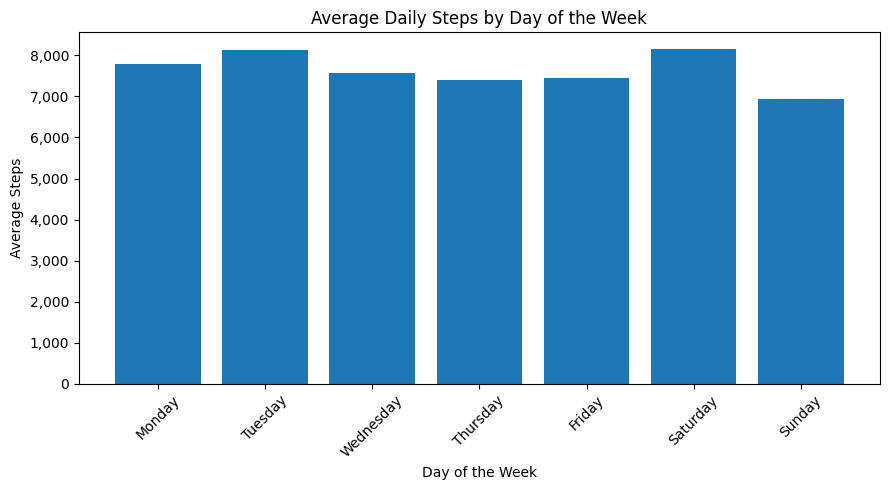

Chart saved to:
/content/drive/MyDrive/Bellabeat Case Study/04 Visualisations/average_steps_by_day.png


In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    activity_by_day.index,
    activity_by_day["average_steps"]
)

plt.title("Average Daily Steps by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.tight_layout()

chart_path = chart_folder / "average_steps_by_day.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:")
print(chart_path)

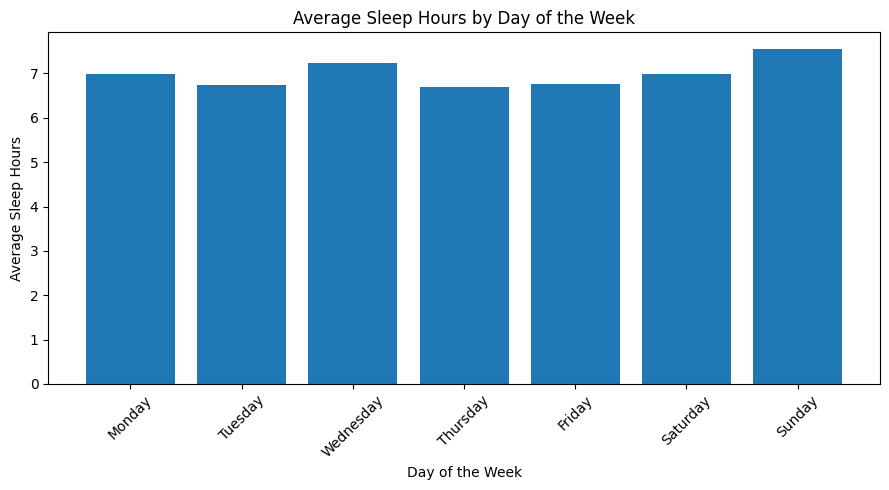

Chart saved to:
/content/drive/MyDrive/Bellabeat Case Study/04 Visualisations/average_sleep_hours_by_day.png


In [26]:
plt.figure(figsize=(9, 5))

plt.bar(
    sleep_by_day.index,
    sleep_by_day["average_sleep_hours"]
)

plt.title("Average Sleep Hours by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Sleep Hours")
plt.xticks(rotation=45)

plt.tight_layout()

chart_path = chart_folder / "average_sleep_hours_by_day.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:")
print(chart_path)

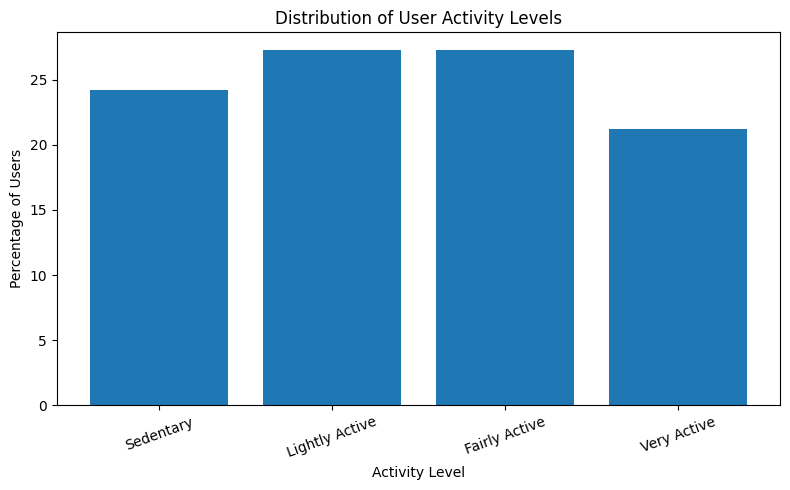

Chart saved to:
/content/drive/MyDrive/Bellabeat Case Study/04 Visualisations/user_activity_levels.png


In [27]:
activity_level_order = [
    "Sedentary",
    "Lightly Active",
    "Fairly Active",
    "Very Active"
]

activity_level_chart = (
    activity_level_summary
    .set_index("ActivityLevel")
    .reindex(activity_level_order)
)

plt.figure(figsize=(8, 5))

plt.bar(
    activity_level_chart.index,
    activity_level_chart["Percentage"]
)

plt.title("Distribution of User Activity Levels")
plt.xlabel("Activity Level")
plt.ylabel("Percentage of Users")
plt.xticks(rotation=20)

plt.tight_layout()

chart_path = chart_folder / "user_activity_levels.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:")
print(chart_path)

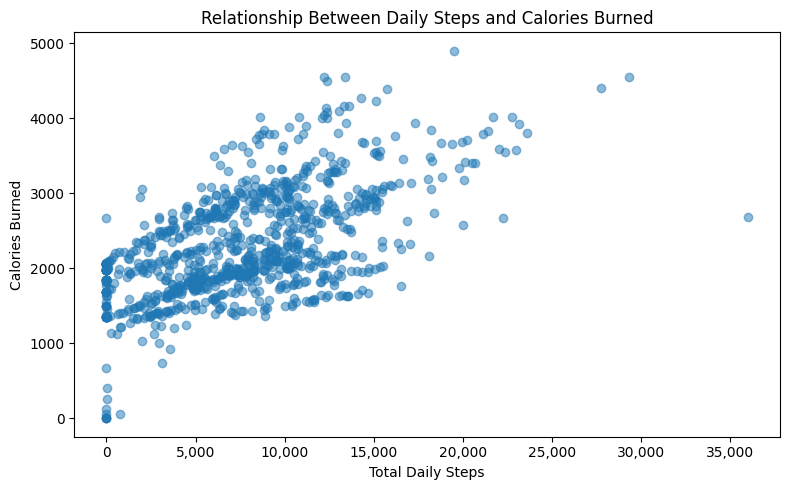

Chart saved to:
/content/drive/MyDrive/Bellabeat Case Study/04 Visualisations/steps_vs_calories.png


In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_activity["TotalSteps"],
    daily_activity["Calories"],
    alpha=0.5
)

plt.title("Relationship Between Daily Steps and Calories Burned")
plt.xlabel("Total Daily Steps")
plt.ylabel("Calories Burned")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}")
)

plt.tight_layout()

chart_path = chart_folder / "steps_vs_calories.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:")
print(chart_path)

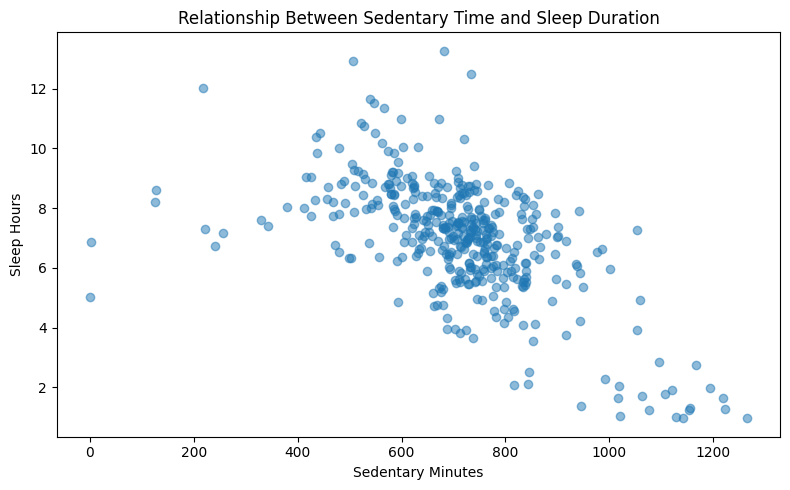

Chart saved to:
/content/drive/MyDrive/Bellabeat Case Study/04 Visualisations/sedentary_time_vs_sleep.png


In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(
    activity_sleep["SedentaryMinutes"],
    activity_sleep["SleepHours"],
    alpha=0.5
)

plt.title("Relationship Between Sedentary Time and Sleep Duration")
plt.xlabel("Sedentary Minutes")
plt.ylabel("Sleep Hours")

plt.tight_layout()

chart_path = chart_folder / "sedentary_time_vs_sleep.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:")
print(chart_path)

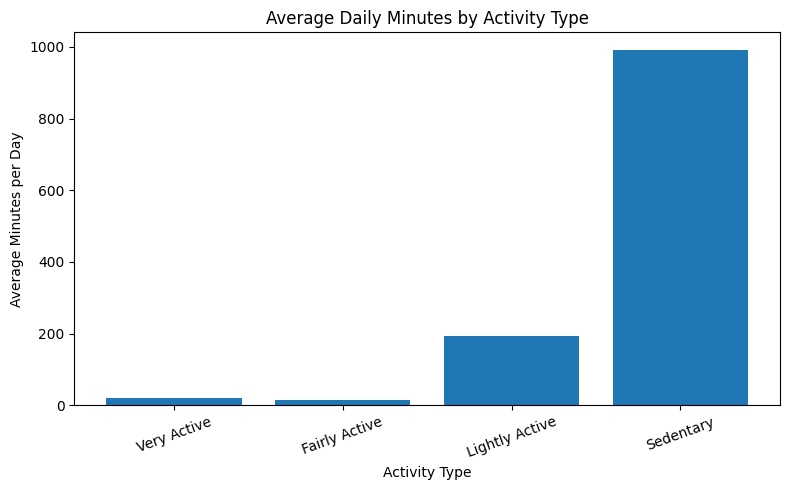

Chart saved to:
/content/drive/MyDrive/Bellabeat Case Study/04 Visualisations/average_minutes_by_activity_type.png


In [30]:
activity_minutes = pd.Series({
    "Very Active": daily_activity["VeryActiveMinutes"].mean(),
    "Fairly Active": daily_activity["FairlyActiveMinutes"].mean(),
    "Lightly Active": daily_activity["LightlyActiveMinutes"].mean(),
    "Sedentary": daily_activity["SedentaryMinutes"].mean()
})

plt.figure(figsize=(8, 5))

plt.bar(
    activity_minutes.index,
    activity_minutes.values
)

plt.title("Average Daily Minutes by Activity Type")
plt.xlabel("Activity Type")
plt.ylabel("Average Minutes per Day")
plt.xticks(rotation=20)

plt.tight_layout()

chart_path = chart_folder / "average_minutes_by_activity_type.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:")
print(chart_path)